In [1]:
import os
import f90nml
import numpy as np
import xarray as xr
os.chdir("/home/philbou/projects/def-rfajber/philbou")
from wva_data.process_run.model_data_loader import MonthlyDataset
from datetime import datetime
import cartopy
cartopy.config['pre_existing_data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
cartopy.config['data_dir'] = '/home/philbou/miniconda3/envs/pro_env/share/cartopy'
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
R=6371e3

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [2]:
monthly_dataset = MonthlyDataset("RT42_sst_0_bucket",360,hemisphere="NH")
t0=datetime.now()
monthly_dataset.add_new_fields_to_ds()
t1=datetime.now()
print(f"Time to add new fields: {t1-t0}")
t0=datetime.now()
monthly_dataset.save_dataset()
t1=datetime.now()

print(f"Time to save dataset: {t1-t0}")
t0=datetime.now()
monthly_dataset.save_monthly_average()
t1=datetime.now()

print(f"Time to save monthly average: {t1-t0}")

Loading dataset from: /home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0360/atmos_monthly
Selected hemisphere: NH, dataset shape: (120, 45, 32, 128)


/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in sqrt
  return func(*(_execute_task(a, cache) for a in args))


(120, 32, 128)
Time to add new fields: 0:00:06.229301
ps float32 pascals
bk float32 none
pk float32 pascals
precipitation float32 kg/m/m/s
t_surf float32 K
flux_lhe float32 watts/m2
flux_t float32 watts/m2
flux_oceanq float32 watts/m2
corr_flux float32 watts/m2
albedo float32 none
sphum float32 kg/kg
ucomp float32 m/sec
vcomp float32 m/sec
omega float32 Pa/sec
wspd float32 m/sec
height float32 m
temp float32 deg_k
vor float32 sec**-1
div float32 sec**-1
sphum_age_1 float32 sec (kg/kg)
sphum_age_2 float32 sec (kg/kg)
cape float32 J/kg
dt_qg_convection float32 kg/kg/s
dt_qg_condensation float32 kg/kg/s
dt_sink float32 kg/kg/s
dt_tracer float32 kg/kg
dt_q float32 kg/kg/s
dt_tracer_diff float32 kg/kg
dt_qg_diffusion float32 kg/kg/s
rh float32 percent
condensation_rain float32 kg/m/m/s
convection_rain float32 kg/m/m/s
olr float32 W/m2
toa_sw float32 W/m2
tdt_rad float32 K/s
tdt_sw float32 K/s
tdt_lw float32 K/s
flux_sw float32 W/m2
flux_lw float32 W/m2
average_T1 object None
average_T2 obje

/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered 

Time to save dataset: 0:00:22.686369


/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in sqrt
  return func(*(_execute_task(a, cache) for a in args))
/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Time to save monthly average: 0:00:04.891939


In [3]:
ds = xr.open_dataset("/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0360/atmos_monthly_wva.nc")
ds_monthly = xr.open_dataset("/home/philbou/scratch/isca_data/RT42_sst_0_bucket/run0360/atmos_monthly_wva_monthly_average.nc")


/home/philbou/miniconda3/envs/pro_env/lib/python3.12/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


In [5]:
ds.mean_age

<xarray.DataArray 'mean_age' (time: 120, pfull: 45, lat: 32, lon: 128)>
[22118400 values with dtype=timedelta64[ns]]
Coordinates:
  * lon      (lon) float64 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * lat      (lat) float64 1.395 4.186 6.977 9.767 ... 79.53 82.31 85.1 87.86
  * time     (time) object 0030-12-01 03:00:00 ... 0030-12-30 21:00:00
  * pfull    (pfull) float64 12.11 14.3 16.85 19.79 ... 923.5 951.3 974.8 992.6
Attributes:
    long_name:  Mean Age of Water Vapor

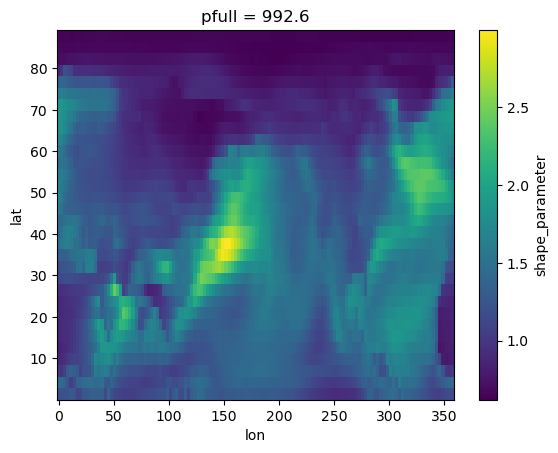

In [5]:
ds_monthly.shape_parameter.isel(pfull = -1).plot()

Text(0.5, 1.0, 'Integrated Water Vapor Shape Parameter 2d')

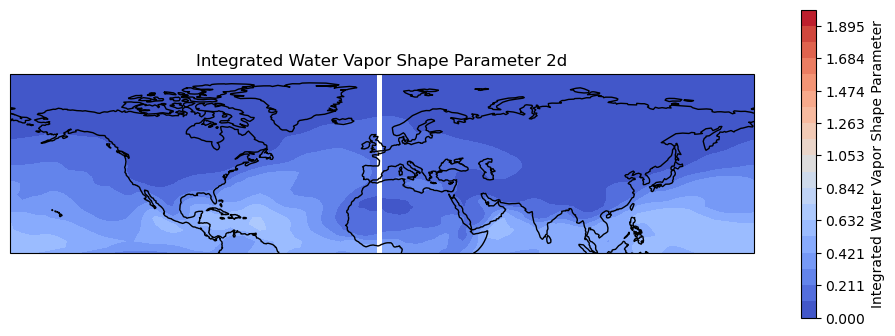

In [12]:
fig,ax1 = plt.subplots(1, 1, figsize=(12, 4),subplot_kw={'projection': ccrs.PlateCarree()})
cb = ax1.contourf(ds_monthly.lon,ds_monthly.lat,ds_monthly.vertically_integrated_shape.values,levels = np.linspace(0,2,20),cmap = 'coolwarm',transform = ccrs.PlateCarree())
ax1.coastlines()
plt.colorbar(cb, ax=ax1, label='Integrated Water Vapor Shape Parameter')
ax1.set_title("Integrated Water Vapor Shape Parameter 2d")

In [7]:

t=20
t0 = datetime.now()


t1 = datetime.now()
print((t1-t0))

0:00:00.000022


In [ ]:
t0= datetime.now()
A = []
for lat_index in range(len(lat_interp)):
    lat_index = int(lat_index)
    equivalent_latitude_at_index = equivalent_latitude[lat_index, :]
    latitude_at_index = lat_values_2d[lat_index, :]
    diff = np.abs(lat_interp[:, None] - equivalent_latitude_at_index[None, :])
    equivalent_latitude_at_index_index = np.argmin(diff, axis=0).astype(int)
    aa = get_A_at_lat(equivalent_latitude_at_index_index,lat_index,lat_interp,CWV_interp,t,R,dlat,dlon)
    A.append(aa)
A_2d = np.array(A)
t1 = datetime.now()
print(120*(t1-t0))

0:00:01.170840


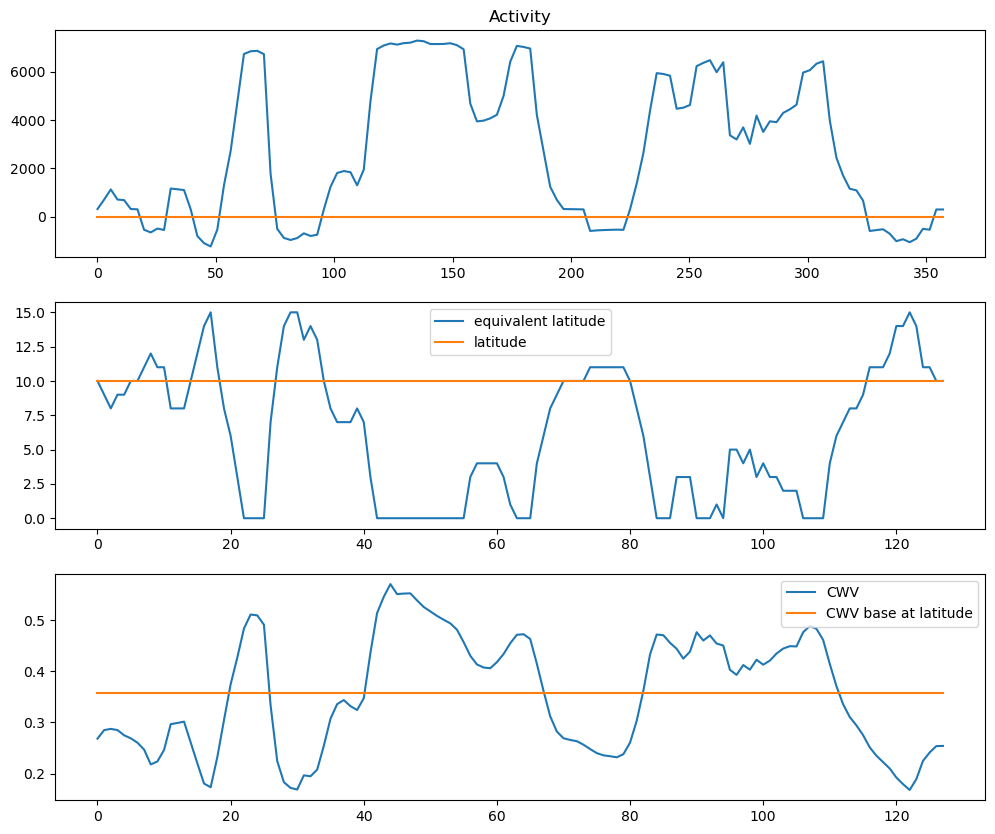

In [ ]:
fig,axs = plt.subplots(3, 1, figsize=(12, 10))

axs[0].plot(lon, aa, label='Equivalent Latitude')
axs[0].plot(lon, np.zeros_like(aa), label='Equivalent Latitude (Index)')
axs[0].set_title("Activity")
axs[1].plot(equivalent_latitude_at_index_index, label = "equivalent latitude")
axs[1].plot(lat_index*np.ones_like(equivalent_latitude_at_index_index), label = "latitude")
axs[1].legend()
axs[2].plot(CWV_interp[t,lat_index,:], label = "CWV")
axs[2].plot(CWV_base_interp[lat_index]*np.ones_like(equivalent_latitude_at_index_index), label = "CWV base at latitude")
axs[2].legend()

Text(0.5, 1.0, 'A+')

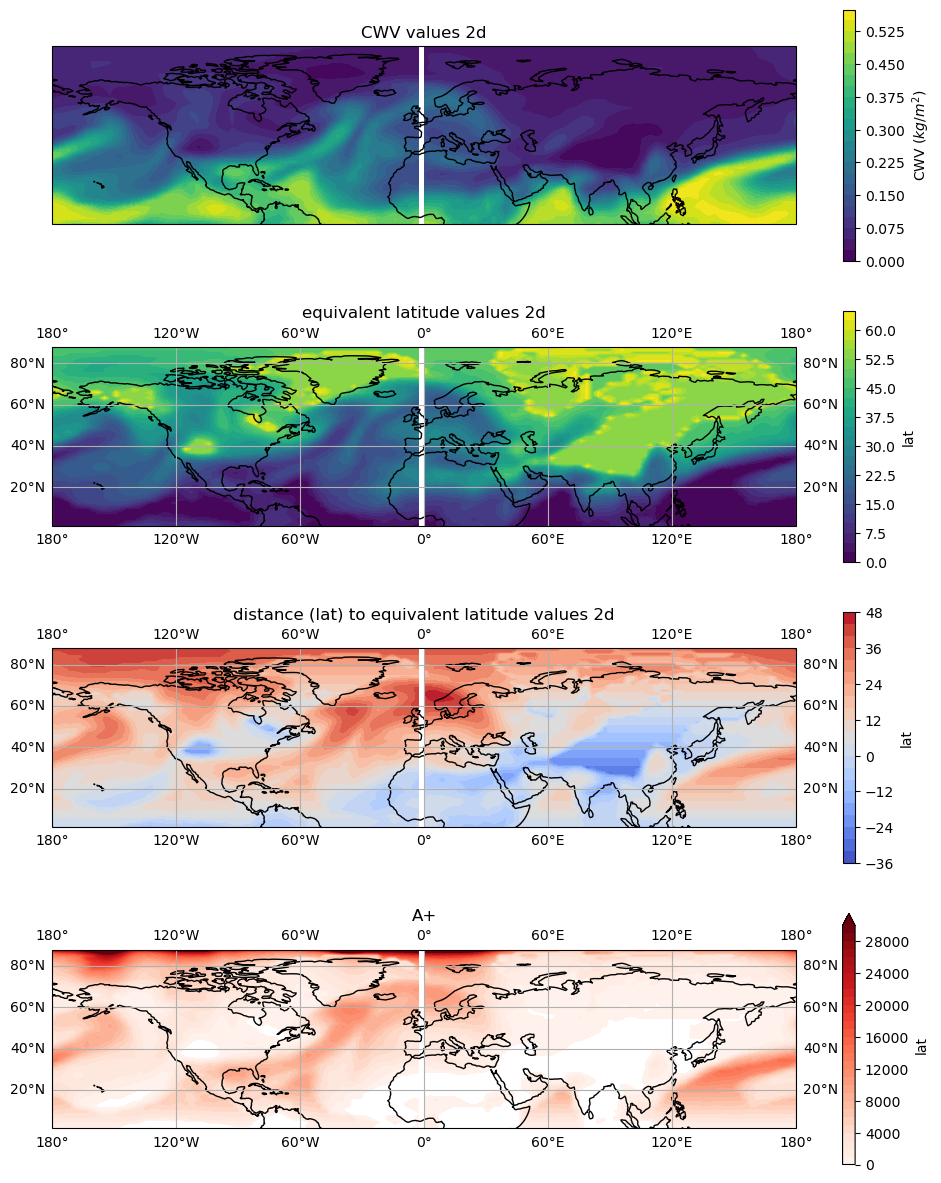

In [ ]:
fig,axs = plt.subplots(4, 1, figsize=(12, 15),subplot_kw={'projection': ccrs.PlateCarree()})
ax0 = axs[0]
cb = ax0.contourf(lon,lat_interp,CWV_interp[t,:,:],levels = 25,cmap = 'viridis',transform = ccrs.PlateCarree())
ax0.coastlines()
plt.colorbar(cb, ax=ax0, label='CWV ($kg/m^2$)')
ax0.set_title("CWV values 2d")



ax1 = axs[1]
cb = ax1.contourf(lon,lat_interp,equivalent_latitude,levels = 25,cmap = 'viridis',transform = ccrs.PlateCarree())
ax1.coastlines()
plt.colorbar(cb, ax=ax1, label='lat')
ax1.set_title("equivalent latitude values 2d")
ax1.gridlines(draw_labels=True)
ax2 = axs[2]
cb2 = ax2.contourf(lon,lat_interp,dist_dx,levels = 25,cmap = 'coolwarm',transform = ccrs.PlateCarree())
ax2.coastlines()
ax2.gridlines(draw_labels=True)
plt.colorbar(cb2, ax=ax2, label='lat')
ax2.set_title("distance (lat) to equivalent latitude values 2d")

ax3 = axs[3]
cb3 = ax3.contourf(lon,lat_interp,A_2d,levels =np.linspace(0,30000,31),extend='max',cmap = 'Reds',transform = ccrs.PlateCarree())
ax3.coastlines()
ax3.gridlines(draw_labels=True)
plt.colorbar(cb3, ax=ax3, label='lat')
ax3.set_title("A+")